# Access the analysis ready UTCI historical data

This notebook provides an example of how to open the derived-utci-historical Zarr store using xarray.
You will need to insert your CDS API key where indicated in the following code cell (available on [your profile page](https://cds.climate.copernicus.eu/profile)).
For more information on using the Data Store Analysis Ready Datasets, please see the [user documentation pages](https://cds.climate.copernicus.eu/datasets/how-to-use-the-dss-arco-dataset).

In [1]:
import os
cdsapi_key = "<INSERT-CDS-API-KEY-HERE>"

# The following attempts to find the CDSAPI in your environment.
if cdsapi_key == "<INSERT-CDS-API-KEY-HERE>":
    cdsapi_key = None
if cdsapi_key is None:
    cdsapi_key = os.getenv("CDSAPI_KEY")
if cdsapi_key is None and os.path.exists(os.path.expanduser("~/.cdsapirc")):
    with open(os.path.expanduser("~/.cdsapirc"), "r") as f:
        for line in f:
            if line.startswith("key:"):
                cdsapi_key = line.split(":")[1].strip()
                break
if cdsapi_key is None:
    raise ValueError("CDSAPI key not found. Please set the CDSAPI_KEY environment variable or create a ~/.cdsapirc file.")
    

## Plug and play access

The code below provides a simple plug and play example of how to use the Zarr Store for light-weight access.

In [2]:
import xarray as xr

# Geo-chunked data (optimised for time-series at a single location)
geochunked_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-004/arco/derived_utci_historical/all/geoChunked.zarr"

# Time-chunked data (optimised for global map at a single time step)
timechunked_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-004/arco/derived_utci_historical/all/timeChunked.zarr"


# Open the zarr store with xarray, users must insert their API key where indicated.
ds = xr.open_zarr(
    geochunked_url,
    consolidated=True,
     storage_options = {
        "headers": {"Authorization": f"Bearer {cdsapi_key}"}
    }
)
 
# Inspect the variables
ds

<xarray.Dataset> Size: 5TB
Dimensions:    (time: 756624, latitude: 601, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 6MB 1940-01-02 ... 2026-04-25T23:00:00
  * latitude   (latitude) float64 5kB -60.0 -59.75 -59.5 ... 89.5 89.75 90.0
  * longitude  (longitude) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
Data variables:
    mrt        (time, latitude, longitude) float32 3TB dask.array<chunksize=(67584, 4, 4), meta=np.ndarray>
    utci       (time, latitude, longitude) float32 3TB dask.array<chunksize=(67584, 4, 4), meta=np.ndarray>
Attributes:
    CDI:                       Climate Data Interface version 1.9.10 (https:/...
    CDO:                       Climate Data Operators version 1.9.10 (https:/...
    Conventions:               CF-1.6
    NCO:                       netCDF Operators version 4.9.7 (Homepage = htt...
    cdo_openmp_thread_number:  8
    history:                   Wed Jan  1 00:02:41 2025: ncatted -a _FillValu...
    institution:               European Centre for Medium-Range Weather Forec...

Extract a point, calculate some aggregations with earthkit-transforms and then plot a time-series using earthkit-plots.

/var/folders/l2/529q7bzs665bnrn7_wjx1nsr0000gn/T/ipykernel_62208/1425807210.py:11: UserWarning: TimeSeries is an experimental new feature in earthkit-plots. We welcome feedback and bug reports on GitHub issues: https://github.com/ecmwf/earthkit-plots/issues
  chart = ekp.TimeSeries()


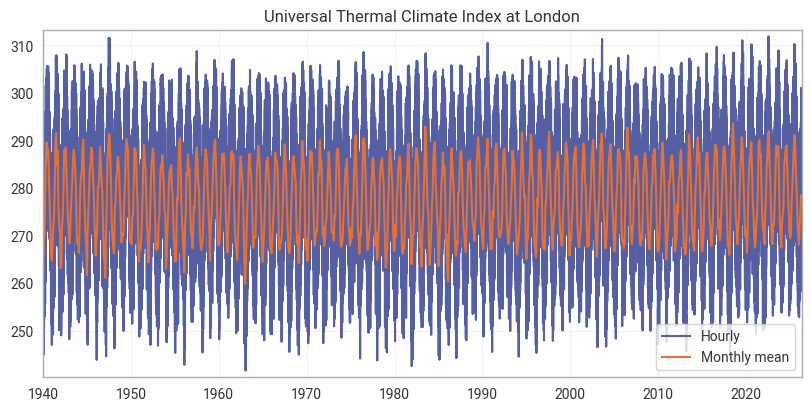

In [3]:
from earthkit import plots as ekp
from earthkit import transforms as ekt

# Select variable to plot
variable_name = "utci"
plot_data_hourly = ds[variable_name].sel(
    latitude=51.5, longitude=-0.1, method="nearest"
)
plot_data_monthly = ekt.temporal.monthly_mean(plot_data_hourly)

chart = ekp.TimeSeries()

chart.line(plot_data_hourly, label="Hourly")
chart.line(plot_data_monthly, label="Monthly mean")

chart.title("Universal Thermal Climate Index at London")
chart.legend()

chart.show()

## Advanced usage

If your workflow requires access to larger amounts of data, it is recommended that you include a retry mechanism.
This is not provided in the current default zarr engine for xarray, instead we can define a custom "`store`" which is
used when connecting to the remote zarr data.

In [4]:
!pip install -q obstore
import xarray as xr
from obstore.store import HTTPStore
from zarr.storage import ObjectStore

# Geo-chunked data (optimised for time-series at a single location)
geochunked_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-004/arco/derived_utci_historical/all/geoChunked.zarr"

# Time-chunked data (optimised for global map at a single time step)
timechunked_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-004/arco/derived_utci_historical/all/timeChunked.zarr"


# Use obstore's HTTPStore to create a store with retry configuration,
# and then wrap it in a zarr ObjectStore to read with xarray.
# See https://github.com/developmentseed/obstore/blob/main/obstore/python/obstore/_store/_retry.pyi
# for more details on the retry configuration options.
http_store = HTTPStore(
    geochunked_url,
    client_options={
        "default_headers": {"Authorization": f"Bearer {cdsapi_key}"},
    },
)
store = ObjectStore(http_store, read_only=True)
ds = xr.open_zarr(store)
ds


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


<xarray.Dataset> Size: 5TB
Dimensions:    (time: 756624, latitude: 601, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 6MB 1940-01-02 ... 2026-04-25T23:00:00
  * latitude   (latitude) float64 5kB -60.0 -59.75 -59.5 ... 89.5 89.75 90.0
  * longitude  (longitude) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
Data variables:
    mrt        (time, latitude, longitude) float32 3TB dask.array<chunksize=(67584, 4, 4), meta=np.ndarray>
    utci       (time, latitude, longitude) float32 3TB dask.array<chunksize=(67584, 4, 4), meta=np.ndarray>
Attributes:
    CDI:                       Climate Data Interface version 1.9.10 (https:/...
    CDO:                       Climate Data Operators version 1.9.10 (https:/...
    Conventions:               CF-1.6
    NCO:                       netCDF Operators version 4.9.7 (Homepage = htt...
    cdo_openmp_thread_number:  8
    history:                   Wed Jan  1 00:02:41 2025: ncatted -a _FillValu...
    institution:               European Centre for Medium-Range Weather Forec...

The result is the same as the previous example, this just provides a more robust connection, preventing your
workflow crashing due to temporary network issues.